### 목표 설정
- 손글씨 숫자 (0~9)를 분류하는 모델을 만들어보자.
- 이미지 데이터의 형태를 이해해보자.
- 분류 모델의 불확실성에 대해 이해해보자.

In [1]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# 데이터 불러오기
digit_data = pd.read_csv('./data/digit_train.csv')
digit_data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# 데이터 살펴보기
# label : 0 ~ 9까지 숫자가 들어있는 컬럼(손글씨가 무슨 숫자인가?) - 정답 데이터
# pixel0 ~ pixel783 : 784개 픽셀 고유 값이 들어있는 컬럼 - 문제 데이터
digit_data.shape   # 데이터 42,000개가 들어있음을 확인

# 이 데이터는 이미지를 표로 바꿔둔 데이터
# 데이터에 대한 정보를 알아보자

(42000, 785)

흑백 이미지 => 색상 채널X (2차원 데이터로 구성)
 - 형태 : (Y,X) = (세로축(행), 가로축(열))

컬러 이미지 => 색상 채널O (3차원 데이터로 구성)
- 형태 : (Y, X, C) = (세로축(행), 가로축(열), 색상채널(R,G,B))

In [5]:
# 우리가 가지고 있는 현재 데이터 => 2차원의 흑백 이미지 데이터 => 1차원의 형태로 만들어 놓은 것
# 42,000 : 이미지의 갯수
# 785 : 정답 포함 / 이미지를 1차원으로 변환해둔 데이터
# 데이터 하나를 뽑아와서 이미지의 형태를 살펴보자
img0 = digit_data.iloc[0, 1 : ]
img0

pixel0      0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Name: 0, Length: 784, dtype: int64

In [6]:
# 값의 최대값 / 최소값 살펴보기
print(img0.max())
print(img0.min())

255
0


In [ ]:
# 현재 데이터는 784개의 픽셀을 1열로 정리해둔 데이터
# 원본 데이터의 사이즈는 행과 열이 28개의 픽셀 값으로 정리가 돼있는 2차원 데이터
img0.values.reshape(28, 28)

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0, 188, 255,  94,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0, 191, 250, 253,  93,   0,   0,   0,
          0,   0],
       [  

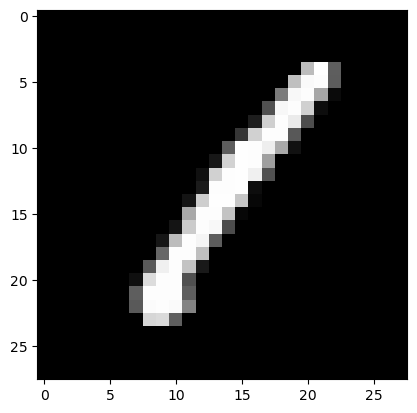

In [20]:
# 현재 1열로 나열 된 데이터를 2차원으로 변환
# 변환한 데이터를 활용해서 이미지를 그려보자
# imshow에서 im은 이미지를 의미 = 이미지를 보여줘!
plt.imshow(img0.values.reshape(28, 28), cmap = 'gray')
plt.show()

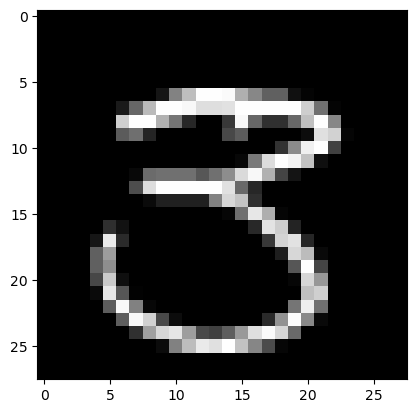

In [ ]:
# 원하는 데이터 빼오기(실습)
img0 = digit_data.iloc[7, 1 : ]
plt.imshow(img0.values.reshape(28, 28), cmap = 'gray')
plt.show()

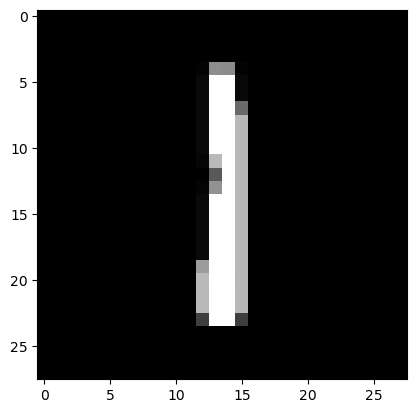

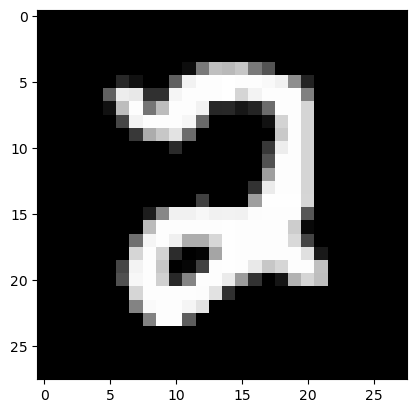

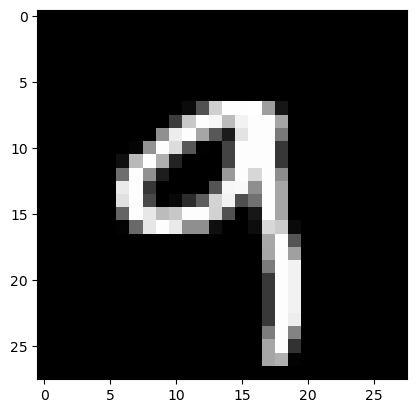

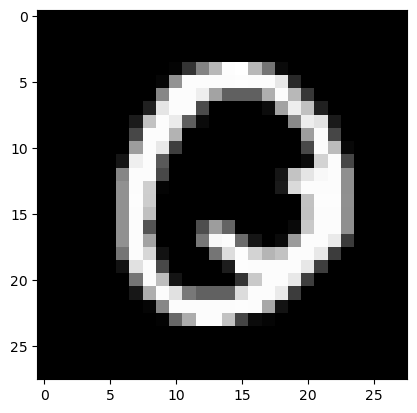

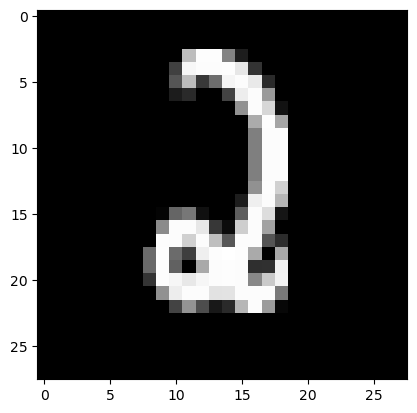

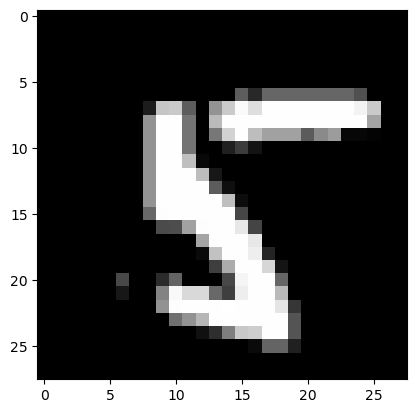

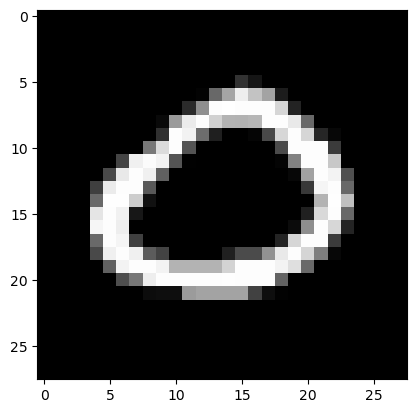

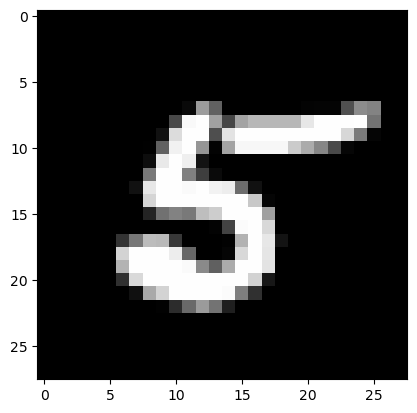

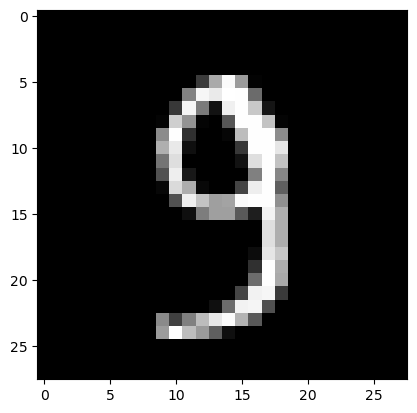

In [46]:
# 반복문으로 이미지 뽑아보기

for i in range(2, 42000, 5000):   # (시작, 끝, n개마다반복)
    img0 = digit_data.iloc[i, 1 : ]
    plt.imshow(img0.values.reshape(28, 28), cmap = 'gray')
    plt.show()

In [47]:
# 정답 데이터 살펴보기
# 정답 데이터의 고유값만 빼오기
digit_data['label']

0        1
1        0
2        1
3        4
4        0
        ..
41995    0
41996    1
41997    7
41998    6
41999    9
Name: label, Length: 42000, dtype: int64

In [48]:
digit_data['label'].unique()

array([1, 0, 4, 7, 3, 5, 8, 9, 2, 6])

In [ ]:
digit_data['label'].value_counts()

label
1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: count, dtype: int64

In [51]:
# 만약 label데이터가 배열이라면 교유값과 갯수를 어떻게 카운트 할 수 있을까?
arr_ = np.array(digit_data['label'])
arr_

array([1, 0, 1, ..., 7, 6, 9], shape=(42000,))

In [52]:
# 고유값을 보는 방법
np.unique(arr_)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [54]:
# 값별 갯수를 카운트하는 방법
np.bincount(arr_)

array([4132, 4684, 4177, 4351, 4072, 3795, 4137, 4401, 4063, 4188])

In [55]:
np.unique(arr_, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([4132, 4684, 4177, 4351, 4072, 3795, 4137, 4401, 4063, 4188]))

In [56]:
# 데이터 분할
X = digit_data.drop('label', axis = 1)
y= digit_data['label']

In [64]:
# train_test_split 함수 불러오기
from sklearn.model_selection import train_test_split

In [65]:
# 데이터 분할하기 / 테스트 비율 : 30% / 랜덤시드 7
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state = 7,
                                                    test_size = 0.3)

In [60]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((29400, 784), (12600, 784), (29400,), (12600,))

In [69]:
# 모델 불러오기
from sklearn.linear_model import LogisticRegression

In [76]:
# 모델 객체 생성
logi = LogisticRegression(max_iter=10000)

In [77]:
# 학습진행
logi.fit(X_train, y_train)

c:\Users\smhrd\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [78]:
# 평가 - score 함수 사용
# 기존의 분류 모델 점수 
logi.score(X_test, y_test)

0.8837301587301587

### 지금까지 살펴 본 모습
1. KNN (실습1) / 결과 : 96%
2. DecisionTree (실습2) / 결과 : 85%
3. 선형 회귀 - 분석 방법이 맞지 않음
4. 선형 분류 - 실습 진행중
 - 남은 KNN / DecisoionTree 모델도 사용해보자

In [ ]:
# 실습 1

# KNN 모델 불러오기
from sklearn.neighbors import KNeighborsClassifier

# 모델 객체 생성
knn = KNeighborsClassifier()

# 모델 학습
knn.fit(X_train, y_train)

# 평가 데이터
knn.score(X_test, y_test)

0.9645238095238096

In [83]:
# 실습 2

# DecisionTree 모델 불러오기
from sklearn.tree import DecisionTreeClassifier

# 객체 생성
tree = DecisionTreeClassifier()

# 모델 학습
tree.fit(X_train, y_train)

# 평가 데이터
tree.score(X_test, y_test)

0.8554761904761905

### 분류의 불확실성

In [84]:
# 모델은 통계적인 계산을 통해 확률 정보를 확인하고 확률 저옵가 가장 높은 정답을 예측
# 분류 모델이 예측한 값에 대한 확률 정보를 확인해보자
knn.predict_proba(X_test)

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(12600, 10))

In [ ]:
# 받아 온 글씨 데이터(0 ~ 9)일 확률을 나타낸 것
knn.predict_proba(X_test)[0]

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
# 임의로 답을 만들어서 확률 계산을 해보기
# [0.4, 0.1, 0., 0., 0., 0., 0., 0., 0.5, 0.]
# 현재 예측 된 값은 얼마이며 예측 확률이 가장 높은 값은 얼마인가?
# 예측 값 : 8 / 예측 확률 : 50%
# 확률 중 가장 높은 값을 추출해서 100을 곱하여 값n일 확률이 50% 이다.
# 0.1인 값이 정답일 경우 분류는 정확한 판단이 불가능 함
# 전체 예측 확률의 값은 1.0(100%)에 해당하는 값을 가지고 있다.